### Import Required libraries

In [34]:
import os
import operator
import functools
import numpy as np
from PIL import Image
from dotenv import load_dotenv
load_dotenv()

# Typing libraries
from typing import List, Dict
from typing_extensions import TypedDict, Annotated

# Data Science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# langchain packages
from langchain_core.messages.base import BaseMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import START, END, StateGraph


# HuggingFace library
from datasets import load_dataset
from transformers import (AutoModelForImageClassification, 
                            AutoImageProcessor)
from transformers import pipeline

### 1. Create a Pneumonia classification

In [36]:
def examine_Xray(patient_x_ray_path, pretrained_model_name_or_path) -> str:

    # load the image from the huggingface 
    dataset = load_dataset('imagefolder', 
                    data_dir = patient_x_ray_path)

    # Randomly choose the image 
    randomInt= np.random.randint(0, len(dataset["train"]))
    randomImg= dataset["train"][randomInt]['image'] # randomly choosen image 
    print(f'Randomly choosen image : {randomInt}')


    processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path)
    model = AutoModelForImageClassification.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path)

    inputs = processor(images = random_img, return_tensors = 'pt')

    # Generate predictions
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = logits.argmax(-1).item()

    # Map the prediction to the class
    classes = model.config.id2label 
    pneumonia_class = classes[predicted_class]

    return pneumonia_class

examine_Xray(
    patient_x_ray_path= 'datasets/input/chest_xray',
    pretrained_model_name_or_path= 'lxyuan/vit-xray-pneumonia-classification'
)

Randomly choosen image : 4031


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 19089.75it/s]


'NORMAL'

#### 1. Define StateSchema

In [35]:
class AgentState(TypedDict):
    initial_prompt :str
    messages : Annotated[List[BaseMessage], operator.add]
    prediction : str 

#### 2. Define Agent Node

In [37]:
def radiologistNode(state, patient_x_ray_path, pretrained_model_name_or_path):
    prediction = examine_Xray(
        patient_x_ray_path= patient_x_ray_path,
        pretrained_model_name_or_path= pretrained_model_name_or_path
    )

    return {'prediction': prediction}

radiologist_agent_node = functools.partial(
    radiologistNode, 
    patient_x_ray_path = 'datasets/input/chest_xray', 
    pretrained_model_name_or_path = 'lxyuan/vit-xray-pneumonia-classification'
)

#### 3. Define Agent Workflow

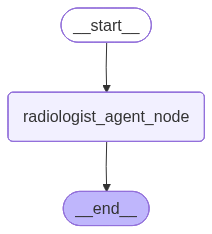

In [39]:
graph = StateGraph(AgentState)

# Adding node to the graph 
graph.add_node('radiologist_agent_node', radiologist_agent_node)

# Adding edged to the graph
graph.add_edge(START, 'radiologist_agent_node')
graph.add_edge('radiologist_agent_node', END)

# Compile the graph
graphWorkflow = graph.compile()
graphWorkflow

In [51]:
initial_prompt = "You are a very experienced radiologist in a Hospital in the India. Diagose if the patient has pneumonia"

# Run the workflow
inputs = {
    "initial_prompt" : initial_prompt
}

graphWorkflow.invoke(inputs)

Randomly choosen image : 2553


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 18091.76it/s]


{'initial_prompt': 'You are a very experienced radiologist in a Hospital in the India. Diagose if the patient has pneumonia',
 'messages': [],
 'prediction': 'NORMAL'}